In [1]:
from MCMC_Algorithms.MCMC import *
from MCMC_Algorithms.Kernels import *
from functools import partial
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import torch

system path ['C:\\Users\\hcw10\\OneDrive\\Documents\\Cambridge-git\\ABC_SMC_RL', 'C:\\Users\\hcw10\\miniconda3\\python39.zip', 'C:\\Users\\hcw10\\miniconda3\\DLLs', 'C:\\Users\\hcw10\\miniconda3\\lib', 'C:\\Users\\hcw10\\miniconda3', '', 'C:\\Users\\hcw10\\miniconda3\\lib\\site-packages', 'C:\\Users\\hcw10\\miniconda3\\lib\\site-packages\\win32', 'C:\\Users\\hcw10\\miniconda3\\lib\\site-packages\\win32\\lib', 'C:\\Users\\hcw10\\miniconda3\\lib\\site-packages\\Pythonwin', '/scratch/Rabbit/work/ABC_SMC_RL/', '/Users/guojiaqi/work/ABC_SMC_RL/']


# 1

In [2]:
def smoothen_max(x,y,alpha=0.1):
    value = torch.cat([x.view(1),y.view(1)])
    return torch.dot(torch.softmax(value/alpha,0),value)

class Modeltest():
    def __init__(self, eps, sigma, z=0.5, r=-0.5, softmax=False, softmax_alpha=0.1):
        self.z = torch.tensor(z)
        self.eps = eps
        self.sigma = sigma
        self.r = torch.tensor(r)
        self.max_fn = torch.max if softmax is False else partial(smoothen_max, alpha=softmax_alpha)
        
    def logtarget_density(self, parameter, **kwargs):
        return self.logtarget_density_eps(parameter=parameter, eps=self.eps, **kwargs)
        
    def logtarget_density_eps(self, parameter, eps, **kwargs):#para_extra_info):
        x = parameter[0]
        y = parameter[1]
        
        
        lp = torch.distributions.Normal(loc=torch.zeros(len(parameter)), scale=self.sigma).log_prob(parameter).sum()
        llh = torch.distributions.Normal(loc=x-self.max_fn(self.z, y), scale=eps).log_prob(self.r).sum()
        return lp+llh, None


    def logtarget_auto_gradient(self, parameter, llh_info_dict=dict()):
        parameter = parameter.clone()
        parameter.requires_grad = True
        logtarget_density, llh_info_dict = self.logtarget_density(parameter=parameter, llh_info_dict=llh_info_dict)
        logtarget_density.backward()
        gradient = parameter.grad.clone()
        parameter.grad.zero_()
        parameter.requires_grad = False
        logtarget_density = logtarget_density.detach()
        return logtarget_density, gradient, llh_info_dict
    
    def logtarget_auto_hessian(self, parameter):
        def fn(parameter):
            logtarget_density, _ = self.logtarget_density(parameter=parameter, llh_info_dict=dict())
            return logtarget_density
        return torch.autograd.functional.hessian(fn, parameter)

In [3]:
#from MCMC import RandomWalk, MALA, MCMC, HMC, mMALA, mHMC
# #kerneltest = RandomWalk(model=Modeltest(), stepsize=stepsize)
# #kerneltest = RandomWalk(model=Modeltest(), stepsize=stepsize, covariance_matrix = torch.tensor([[.1]]))
# #kerneltest = MALA(model=Modeltest(), stepsize=stepsize, precondition_matrix = torch.tensor([[.1]]))
# kerneltest = MALA(model=Modeltest(), stepsize=stepsize, precondition_matrix = torch.tensor([[.1]]))
# #kerneltest = HMC(model=Modeltest(), stepsize=stepsize, num_steps=20)
# #kerneltest = HMC(model=Modeltest(), stepsize=stepsize, num_steps=20, precondition_matrix = torch.tensor([[0.1]]))
# #kerneltest = mMALA(model=Modeltest(), stepsize=stepsize)
# #kerneltest = mHMC(model=Modeltest(), stepsize=stepsize, num_steps=20)
kerneltest = HMC(model=model, stepsize=stepsize, num_steps=20, use_autograd=True, mass=1, precondition_matrix=None, traj_len=None)


NameError: name 'model' is not defined

In [3]:
def run_mcmc(kernel, eps, sigma, num_samples, initial_params, hessian_params, kernel_settings):
    
    model = Modeltest(eps=eps, sigma=sigma)
    if kernel_settings.get("precondition_matrix") is True:
        precondition_matrix = - torch.linalg.inv(model.logtarget_auto_hessian(hessian_params) - 1e-6 * torch.eye(len(hessian_params)))
        kernel_settings["precondition_matrix"] = precondition_matrix
        print("precondition", precondition_matrix)

    kernel = kernel(model=model, **kernel_settings)
    mcmc = MCMC(num_samples=num_samples, kernel=kernel, initial_params=initial_params, warmup_steps=0)
    sample = mcmc.run(idx=None).numpy()
    return sample

def plot_result(samples, bins=100):
    
    plt.hist2d(samples[:,0], samples[:,1], bins=bins, density=True);
    plt.show()
    
    plt.figure()
    plt.axhline(0.5, color="red")
    plt.plot(samples[:,0], alpha=0.5)
    plt.plot(sample[:,1], alpha=0.5)
    plt.show()

In [6]:
def ESS(weights):
    return 1 / np.sum(weights ** 2)

def SMC(kernel, eps0, eps_f, n_particles, sigma, kernel_settings, c=0.9):
    
    weights_ls = []
    particles_ls = []
    ess_ls = []
    
    model = Modeltest(eps=eps0, sigma=sigma)

    eps = eps0
    weights = np.ones(n_particles) / n_particles
    particles = torch.distributions.normal.Normal(loc=torch.zeros(2), scale=sigma).sample((n_particles,))
    
    weights_ls.append(weights)
    particles_ls.append(particles.numpy())
    ess_ls.append(n_particles)
    
    weights *= np.array([model.logtarget_density_eps(particles[i], eps=eps)[0].numpy() for i in range(n_particles)])
    weights = weights / np.sum(weights)
    
    ess = ESS(weights)
    ess_ls.append(ess)

    if ess < 0.5 * n_particles:
        particles = particles[torch.multinomial(weights, n_particles, replacement=True)]
        weights[i] = 1 / n_particles

    for i in range(n_particles):
        particles[i] = torch.tensor(run_mcmc(kernel=kernel, eps=eps, sigma=sigma, num_samples=5, initial_params=particles[i], hessian_params=particles[i], kernel_settings=kernel_settings)[-1])
        
    weights_ls.append(weights)
    particles_ls.append(particles.numpy())

    while eps > eps_f:
        new_eps = c*eps
        update = np.array([model.logtarget_density_eps(particles[i], eps=new_eps)[0].numpy()/ model.logtarget_density_eps(particles[i], eps=eps)[0].numpy() for i in range(n_particles)])
        weights *= update
        weights = weights / np.sum(weights)

        ess = ESS(weights)
        ess_ls.append(ess)

        if ess < 0.5 * n_particles:
            particles = particles[torch.multinomial(weights, n_particles, replacement=True)]
            weights[i] = 1 / n_particles

        for i in range(n_particles):
            particles[i] = torch.tensor(run_mcmc(kernel=kernel, eps=new_eps, sigma=sigma, num_samples=5, initial_params=particles[i], hessian_params=particles[i], kernel_settings=kernel_settings)[-1])
            
        weights_ls.append(weights)
        particles_ls.append(particles.numpy())

        eps = new_eps

    return particles.numpy(), weights_ls, particles_ls, ess_ls

In [ ]:
kernel_settings = dict(stepsize=0.0019, num_steps=20, use_autograd=True, mass=1, precondition_matrix=None, traj_len=None)
samples = run_mcmc(kernel=HMC, eps=0.001, sigma=2, num_samples=50000, initial_params=torch.zeros(2) , hessian_params=torch.zeros(2), kernel_settings=kernel_settings)

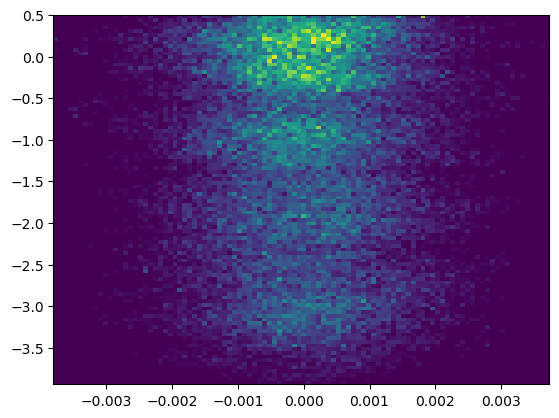

In [57]:
plt.hist2d(samplestest[:,0], samplestest[:,1], bins=100, density=True);

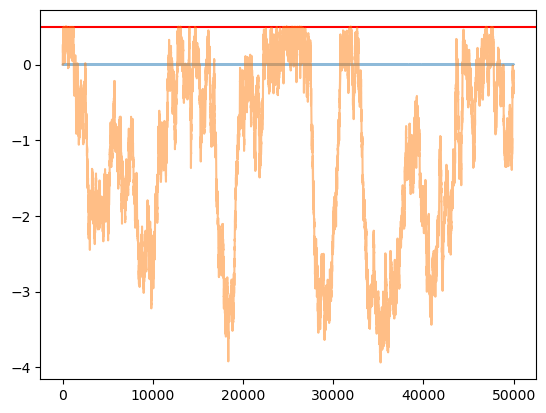

In [58]:
plt.figure()
plt.axhline(0.5, color="red")
plt.plot(samplestest[:,0], alpha=0.5)
plt.plot(samplestest[:,1], alpha=0.5)

In [140]:
stepsize

0.0019

# 2

In [ ]:
kernel_settings = dict(stepsize=0.05, num_steps=20, use_autograd=True, mass=1, precondition_matrix=True, traj_len=None)
samples = run_mcmc(kernel=HMC, eps=0.001, sigma=2, num_samples=50000, initial_params=torch.tensor([1.,1.5]) , hessian_params=torch.tensor([1.,1.5]), kernel_settings=kernel_settings)

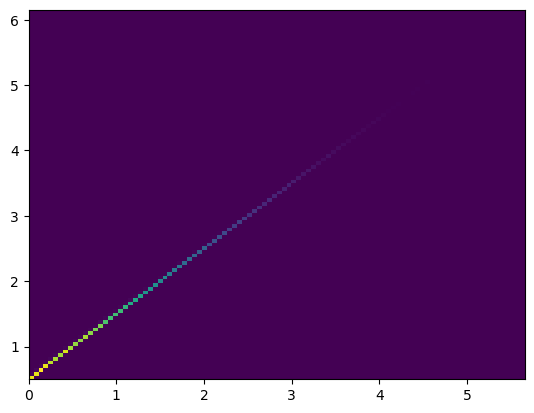

In [102]:
plt.hist2d(samplestest[:,0], samplestest[:,1], bins=100, density=True);
#plt.plot(grid, stats.laplace.pdf(grid, loc=2, scale=1));

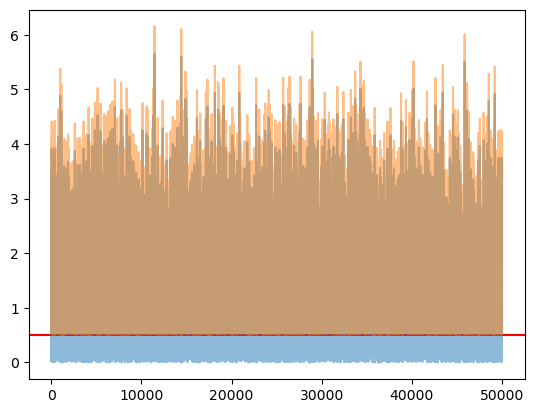

In [103]:
plt.figure()
plt.axhline(0.5, color="red")
plt.plot(samplestest[:,0], alpha=0.5)
plt.plot(samplestest[:,1], alpha=0.5)

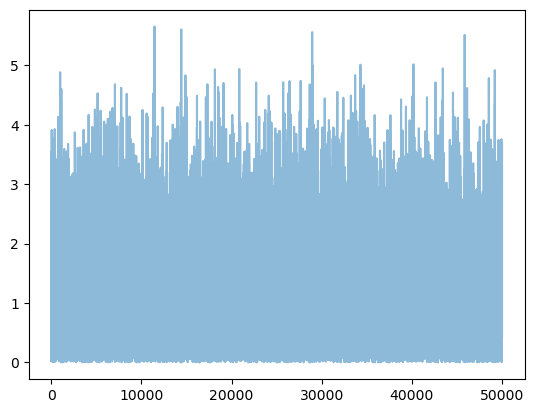

In [110]:
plt.figure()
plt.plot(samplestest[:,0], alpha=0.5)

# 3

In [129]:
kernel_settings = dict(stepsize=0.001, num_steps=20, use_autograd=True, mass=1, precondition_matrix=True, traj_len=None)
samples = run_mcmc(kernel=HMC, eps=0.001, sigma=2, num_samples=50000, initial_params=torch.tensor([0.,0.5]) , hessian_params=torch.tensor([0.,0.5]) , kernel_settings=kernel_settings)

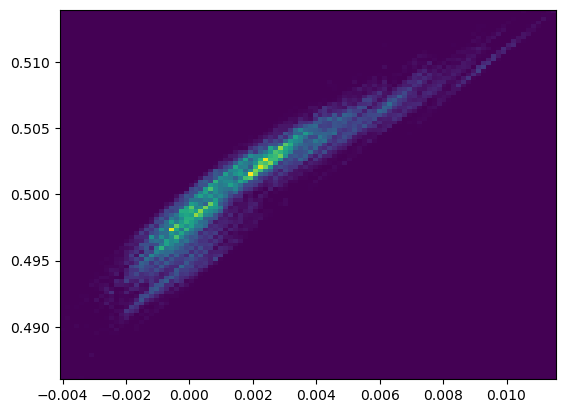

In [113]:
plt.hist2d(samplestest[:,0], samplestest[:,1], bins=100, density=True);

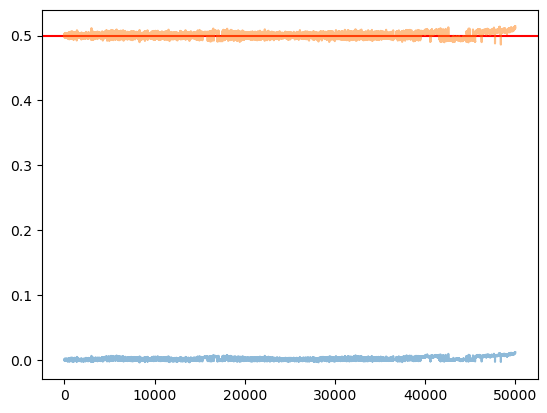

In [114]:
plt.figure()
plt.axhline(0.5, color="red")
plt.plot(samplestest[:,0], alpha=0.5)
plt.plot(samplestest[:,1], alpha=0.5)

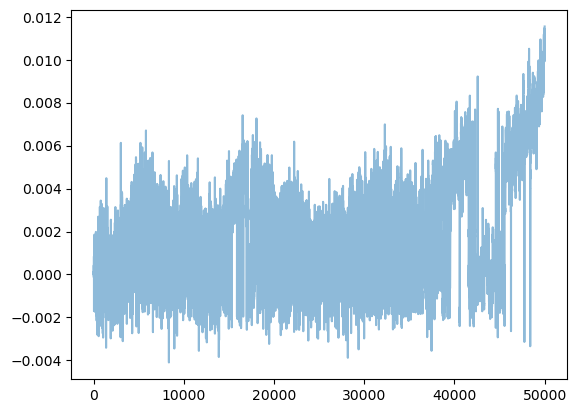

In [115]:
plt.figure()
plt.plot(samplestest[:,0], alpha=0.5)

# 4

In [ ]:
kernel_settings = dict(stepsize=0.0019, num_steps=20, use_autograd=True, mass=1, precondition_matrix=None, traj_len=None)
samples = run_mcmc(kernel=HMC, eps=0.001, sigma=2, num_samples=50000, softmax=True, softmax_alpha=1, initial_params=torch.tensor([0.,0.]), hessian_params=torch.tensor([0.,0.]), kernel_settings=kernel_settings)

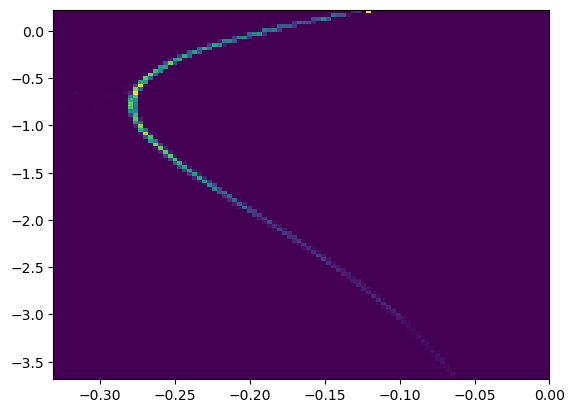

In [94]:
plt.hist2d(samplestest[:,0], samplestest[:,1], bins=100, density=True);

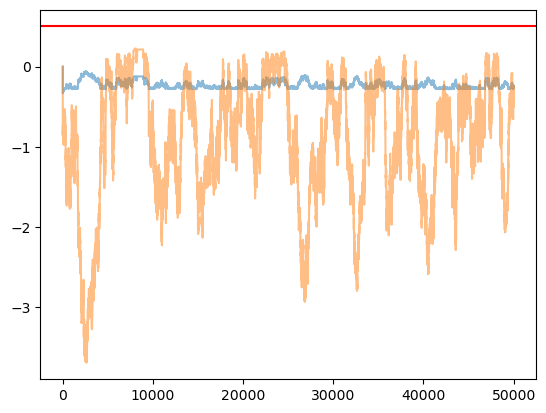

In [95]:
plt.figure()
plt.axhline(0.5, color="red")
plt.plot(samplestest[:,0], alpha=0.5)
plt.plot(samplestest[:,1], alpha=0.5)

In [ ]:
for s in [0.1,0.01,0.001,0.0001]:
    for e in [1,0.1,0.01,0.001]:
        print(s, e)
        try:
            kernel_settings = dict(stepsize=s, num_steps=50, use_autograd=True, mass=1, precondition_matrix=None, traj_len=None)
            samples = run_mcmc(kernel=HMC, eps=e, sigma=2, num_samples=50000, initial_params=torch.zeros(2) , hessian_params=torch.zeros(2), kernel_settings=kernel_settings)
        except:
            print("unable to sample at this s,e")

        np.save("./test_mcmc/MCMCs{}-e{}".format(str(s), str(e)), samples)


In [ ]:
kernel_settings = dict(stepsize=0.0019, num_steps=20, use_autograd=True, mass=1, precondition_matrix=None, traj_len=None)
samples_smc, weights_ls, samples_smc_ls, ess_ls = SMC(kernel=HMC, eps0=10, eps_f=1, n_particles=100, sigma=2, kernel_settings=kernel_settings, c=0.95)

HMC stepsize 0.0019


  0%|          | 0/5 [00:00<?, ?it/s]

HMC stepsize 0.0019


  0%|          | 0/5 [00:00<?, ?it/s]

HMC stepsize 0.0019


...

  0%|          | 0/5 [00:00<?, ?it/s]

HMC stepsize 0.0019


  0%|          | 0/5 [00:00<?, ?it/s]

HMC stepsize 0.0019


  0%|          | 0/5 [00:00<?, ?it/s]

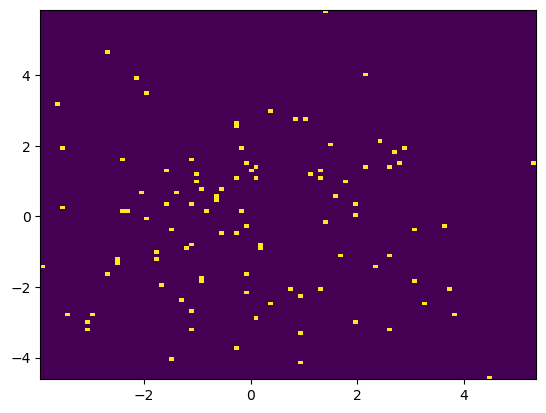

In [64]:
plt.hist2d(samples_smc.numpy()[:,0], samples_smc.numpy()[:,1], bins=100);

In [61]:
samples_smc

tensor([[-2.0118,  0.6762],
        [ 0.9363, -2.2596],
        [-0.9167, -1.7093],
        [ 1.9270,  0.0516],
        [ 1.3110,  1.1011],
        [ 2.8782,  1.9782],
        [ 0.9119, -3.2844],
        [ 2.5761, -1.0815],
        [-3.5460,  0.2051],
        [ 1.6077,  0.5971],
        [-0.3106,  2.6486],
        [-1.7474, -1.1869],
        [-1.4535, -0.3904],
        [ 1.4728,  2.0466],
        [ 3.8377, -2.7876],
        [-2.3446,  0.1632],
        [-1.0852,  0.3510],
        [-0.5821, -0.4849],
        [-1.6501, -1.9314],
        [-0.0190,  1.3139],
        [ 1.9806,  0.3562],
        [-3.9460, -1.3968],
        [ 0.2132, -0.8928],
        [-0.2745, -0.4297],
        [ 3.0552, -1.7904],
        [ 2.4046,  2.1263],
        [ 3.0786, -0.3403],
        [ 1.8146,  1.0207],
        [-1.2922, -2.3887],
        [ 3.6227, -0.2731],
        [ 1.3579,  5.8542],
        [ 0.3582, -2.5165],
        [ 0.1209,  1.1388],
        [-1.0206,  0.9833],
        [-0.0789, -2.1291],
        [ 2.3370, -1